# Assignment-11: Time Series Analysis and Forecasting
### Setup & Data Loading

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Change mean_absolute_percent to mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

### Problem Setup & EDA

Dataset Shape: (397, 1)

Summary Statistics:
        Production
count  397.000000
mean    88.847218
std     15.387834
min     55.315100
25%     77.105200
50%     89.779500
75%    100.524400
max    129.404800


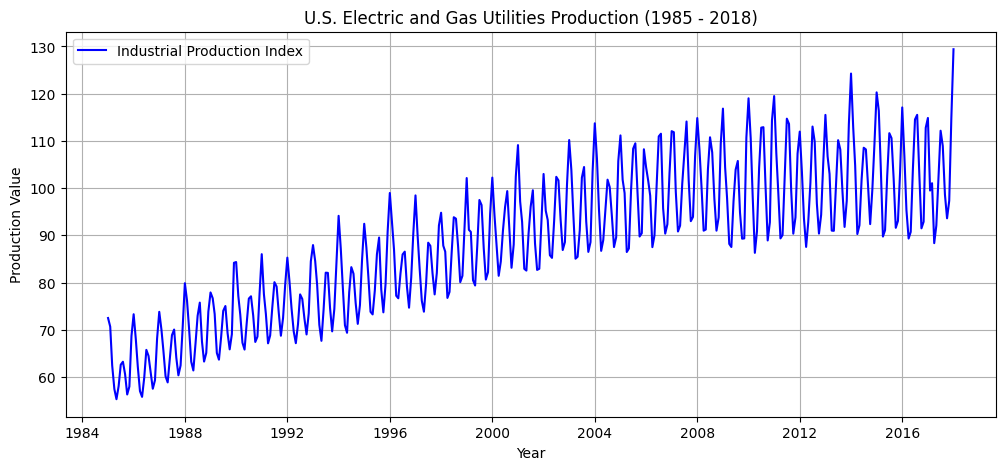

In [11]:
df = pd.read_csv('./Electric_Production.csv')

# 2. Parse dates and set as index
df['DATE'] = pd.to_datetime(df['DATE'])
df.set_index('DATE', inplace=True)
df.columns = ['Production']

# 3. Initial inspection
print("Dataset Shape:", df.shape)
print("\nSummary Statistics:\n", df.describe())

# 4. Time Plot
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Production'], label='Industrial Production Index', color='blue')
plt.title('U.S. Electric and Gas Utilities Production (1985 - 2018)')
plt.xlabel('Year')
plt.ylabel('Production Value')
plt.grid(True)
plt.legend()
plt.show()

### Preprocessing & Decomposition

Missing values count:
 Production    0
dtype: int64


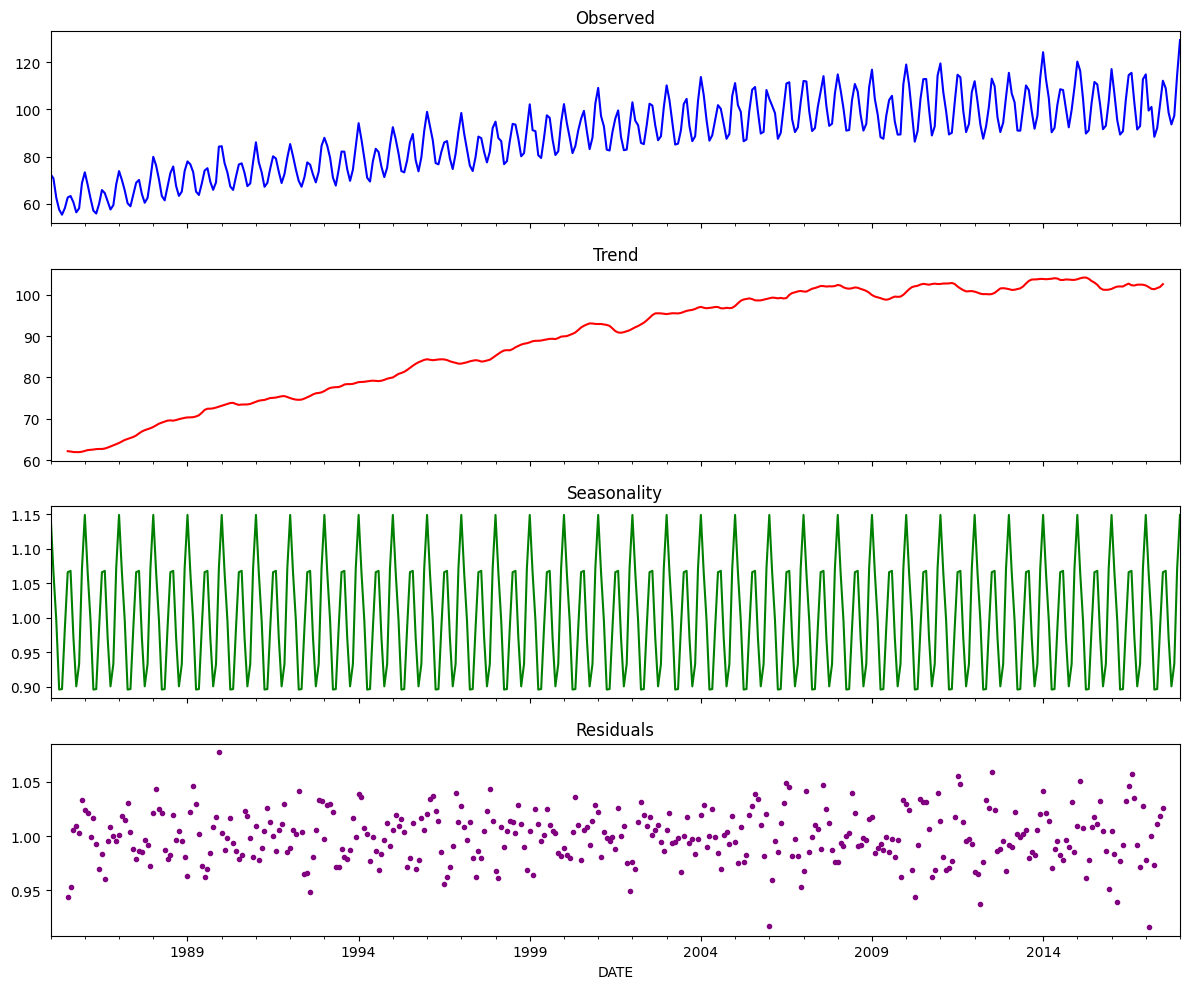

--- Stationarity Test on Raw Data ---
Augmented Dickey-Fuller Test Metrics:
ADF Statistic: -2.2570
p-value: 0.1862
Critical Values:
   1%: -3.4476
   5%: -2.8692
   10%: -2.5708

--- Stationarity Test after 12-Month Seasonal Differencing ---
Augmented Dickey-Fuller Test Metrics:
ADF Statistic: -5.6735
p-value: 0.0000
Critical Values:
   1%: -3.4481
   5%: -2.8693
   10%: -2.5709


In [12]:
print("Missing values count:\n", df.isnull().sum())


decomposition = seasonal_decompose(df['Production'], model='multiplicative', period=12)


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=ax1, color='blue', title='Observed')
decomposition.trend.plot(ax=ax2, color='red', title='Trend')
decomposition.seasonal.plot(ax=ax3, color='green', title='Seasonality')
decomposition.resid.plot(ax=ax4, color='purple', style='.', title='Residuals')
plt.tight_layout()
plt.show()


def check_stationarity(timeseries):
    result = adfuller(timeseries.dropna())
    print('Augmented Dickey-Fuller Test Metrics:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

print("--- Stationarity Test on Raw Data ---")
check_stationarity(df['Production'])


df['Diff_12'] = df['Production'].diff(12) 
print("\n--- Stationarity Test after 12-Month Seasonal Differencing ---")
check_stationarity(df['Diff_12'])

### Train-Test Split & Baseline Model Fitting

In [14]:
test_months = 36
train = df.iloc[:-test_months]['Production']
test = df.iloc[-test_months:]['Production'] 


naive_forecast = train.iloc[-12:].tolist() * (test_months // 12)
naive_forecast = pd.Series(naive_forecast, index=test.index)


ma_baseline_value = train.rolling(window=12).mean().iloc[-1]
ma_forecast = pd.Series([ma_baseline_value] * test_months, index=test.index)

print(f"Train dataset size: {len(train)} months")
print(f"Test dataset size: {len(test)} months")

Train dataset size: 361 months
Test dataset size: 36 months


### Advanced Model Fitting

In [15]:

hw_model = ExponentialSmoothing(train, trend='mul', seasonal='mul', seasonal_periods=12).fit()
hw_forecast = hw_model.forecast(test_months)


sarima_model = SARIMAX(train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False).fit(disp=False)
sarima_forecast = sarima_model.forecast(test_months)

print("Advanced models trained successfully.")

d:\Softwares\Git\LogicMojo-AI-ML-Sept25-arunkumar0816\LogicMojo-AI-ML-Sept25-arunkumar0816\assignments\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Softwares\Git\LogicMojo-AI-ML-Sept25-arunkumar0816\LogicMojo-AI-ML-Sept25-arunkumar0816\assignments\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\Softwares\Git\LogicMojo-AI-ML-Sept25-arunkumar0816\LogicMojo-AI-ML-Sept25-arunkumar0816\assignments\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Advanced models trained successfully.


### Model Forecasting & Evaluation


=== Model Evaluation Table ===
         Model    RMSE    MAE  MAPE (%)
Seasonal Naive  4.6410 3.4957    3.3337
Moving Average 10.1162 8.4897    8.3137
  Holt-Winters  5.2890 4.2629    4.2527
        SARIMA  4.1092 3.2004    3.1240


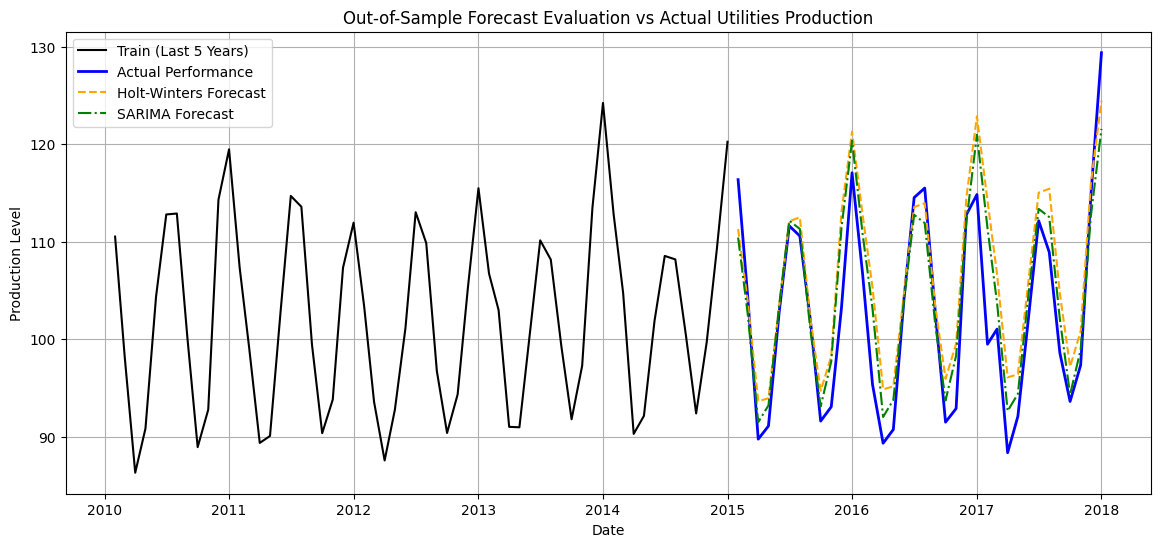

In [16]:

def evaluate_forecast(actual, predicted, model_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    return {"Model": model_name, "RMSE": round(rmse, 4), "MAE": round(mae, 4), "MAPE (%)": round(mape, 4)}


metrics_summary = [
    evaluate_forecast(test, naive_forecast, "Seasonal Naive"),
    evaluate_forecast(test, ma_forecast, "Moving Average"),
    evaluate_forecast(test, hw_forecast, "Holt-Winters"),
    evaluate_forecast(test, sarima_forecast, "SARIMA")
]


performance_df = pd.DataFrame(metrics_summary)
print("\n=== Model Evaluation Table ===")
print(performance_df.to_string(index=False))


plt.figure(figsize=(14, 6))
plt.plot(train.index[-60:], train.tail(60), label='Train (Last 5 Years)', color='black')
plt.plot(test.index, test, label='Actual Performance', color='blue', linewidth=2)
plt.plot(test.index, hw_forecast, label='Holt-Winters Forecast', color='orange', linestyle='--')
plt.plot(test.index, sarima_forecast, label='SARIMA Forecast', color='green', linestyle='-.')
plt.title('Out-of-Sample Forecast Evaluation vs Actual Utilities Production')
plt.xlabel('Date')
plt.ylabel('Production Level')
plt.legend()
plt.grid(True)
plt.show()

### Diagnostics (Residual Analysis)

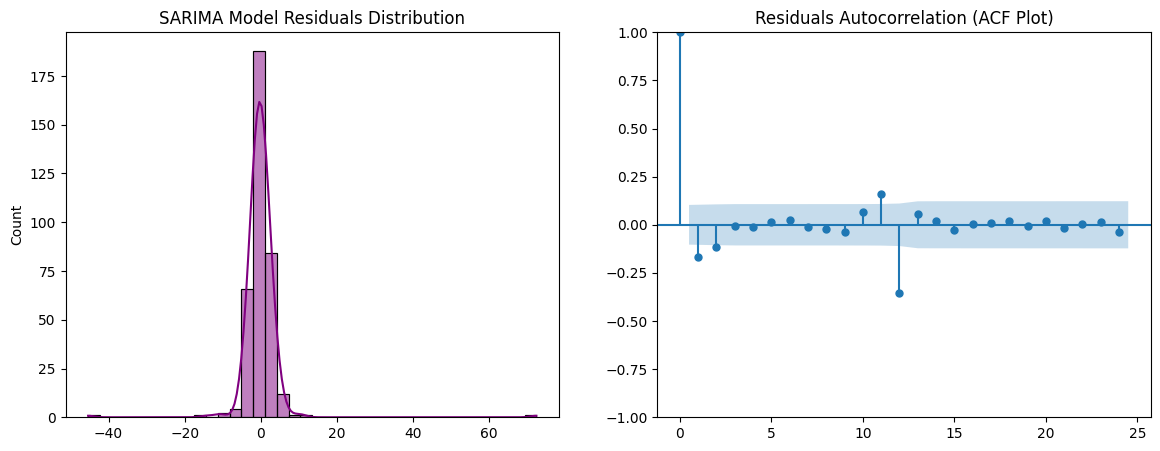

Residual verification complete. If residuals are white noise, model captures underlying dynamics.


In [17]:

residuals = sarima_model.resid

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, kde=True, ax=ax[0], color='purple')
ax[0].set_title('SARIMA Model Residuals Distribution')

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, ax=ax[1], lags=24)
ax[1].set_title('Residuals Autocorrelation (ACF Plot)')
plt.show()

print("Residual verification complete. If residuals are white noise, model captures underlying dynamics.")